In [3]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
X = 6* np.random.rand(100,1) -3
y = 0.5*X**2 +1.5*X +2 + np.random.randn(100,1)

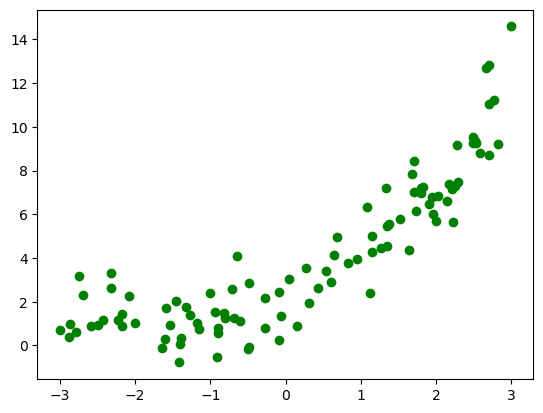

In [20]:
plt.scatter(X,y,color='g')

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.2, random_state=42)

In [24]:
#let implement simple linear model
from sklearn.linear_model import LinearRegression

In [26]:
regressor = LinearRegression()

In [28]:
regressor.fit(X_train,y_train)

LinearRegression()

In [30]:
from sklearn.metrics import r2_score

In [32]:
score = r2_score(y_test, regressor.predict(X_test))

In [34]:
score

0.7346511619625258

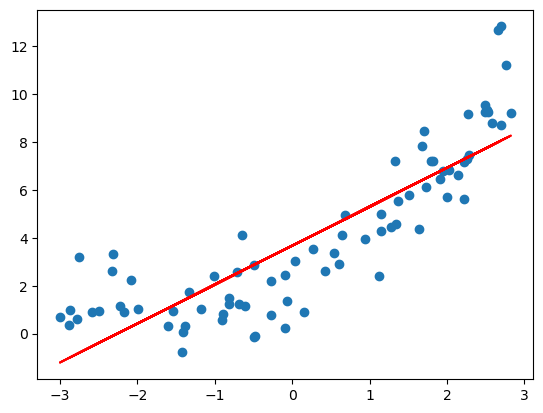

In [38]:
plt.plot(X_train,regressor.predict(X_train), color = 'r')
plt.scatter(X_train,y_train)

### Polinomial Regression

In [41]:
from sklearn.preprocessing import PolynomialFeatures

In [43]:
poly = PolynomialFeatures(degree=2,include_bias=True) #if degree is 2

In [45]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [47]:
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly,y_train)
y_pred = poly_reg.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.9120506008621964


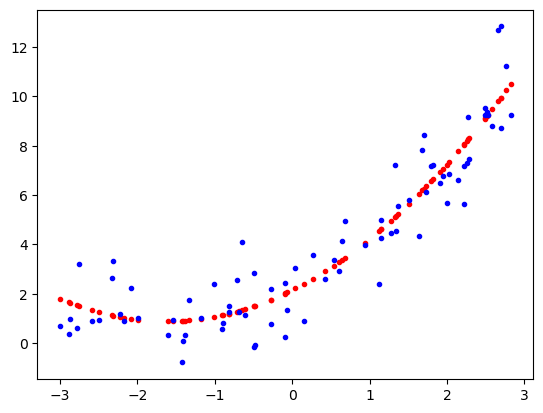

In [170]:
ply = poly_reg.predict(X_train_poly)
plt.plot(X_train, ply,'r.' ,label='Polynomial',linewidth=2)
plt.plot(X_train,y_train ,"b.")


In [75]:
#prediction of new data
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform

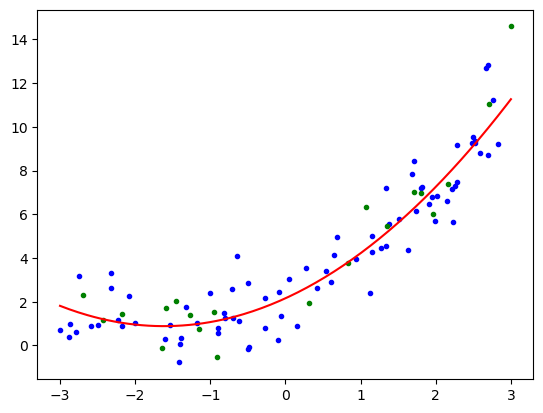

In [150]:
y_new = poly_reg.predict(X_new_poly)
plt.plot(X_train , y_train , 'b.')
plt.plot(X_test,y_test , 'g.')
plt.plot(X_new,y_new ,'r-')

## Pipeline

In [173]:
from sklearn.pipeline import Pipeline

In [205]:
def poly_regression(degree):
    X_new = np.linspace(-3,3,200).reshape(200,1)
    poly_features = PolynomialFeatures(degree=degree,include_bias=True)
    print('-')
    lin_reg=LinearRegression()
    poly_reg_p = Pipeline([
        ('Poly_features',poly_features),
        ('Linear regression',lin_reg)
    ])
    poly_reg_p.fit(X_train,y_train)
    y_pred = poly_reg_p.predict(X_new)
    #plotting
    plt.plot(X_train,y_train , 'b.')
    plt.plot(X_test,y_test,'g.')
    plt.plot(X_new,y_pred ,'r-')
    

-


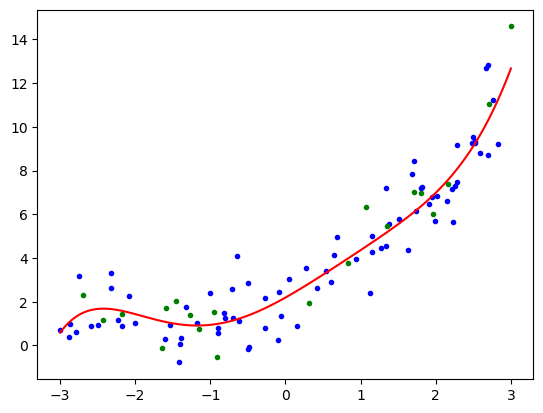

In [209]:
poly_regression(6)